In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import RobustScaler


In [ ]:
df = pd.read_csv("node_combined.csv")

In [ ]:
## pisahin node menjadi per df

df1 = df[df['node'] == 1].copy()
df2 = df[df['node'] == 2].copy()
df3 = df[df['node'] == 3].copy()
df4 = df[df['node'] == 4].copy()
df5 = df[df['node'] == 5].copy()
df6 = df[df['node'] == 6].copy()

# tampilkan head df1-6
for i in range(1, 7):
    print(f"\nNode {i} (df{i}) head:")
    print(globals()[f"df{i}"].head(1))


Node 1 (df1) head:
   node         location weather             datetime   h2s    so2    hum  \
0     1  Dekat uap panas   Cerah  2025-12-22 11:53:00  43.0  149.0  87.03   

    temp  windspeed  elevation  latitude   longitude  
0  17.94       1.44     2101.0  -7.16687  107.401387  

Node 2 (df2) head:
     node               location  weather             datetime   h2s   so2  \
739     2  Dekat sumber mata air  Mendung  2025-12-22 13:25:00  18.0  36.0   

       hum   temp  windspeed  elevation  latitude   longitude  
739  83.37  19.41       5.76     2195.0 -7.167397  107.401775  

Node 3 (df3) head:
      node    location  weather             datetime    h2s    so2    hum  \
1582     3  Hutan Mati  Mendung  2025-12-22 15:25:00  121.0  453.0  95.85   

       temp  windspeed  elevation  latitude   longitude  
1582  17.57       4.32     2196.0 -7.167415  107.402914  

Node 4 (df4) head:
      node         location      weather             datetime   h2s   so2  \
1829     4  Area Pengu


======== Processing df1 (Node 1) ========



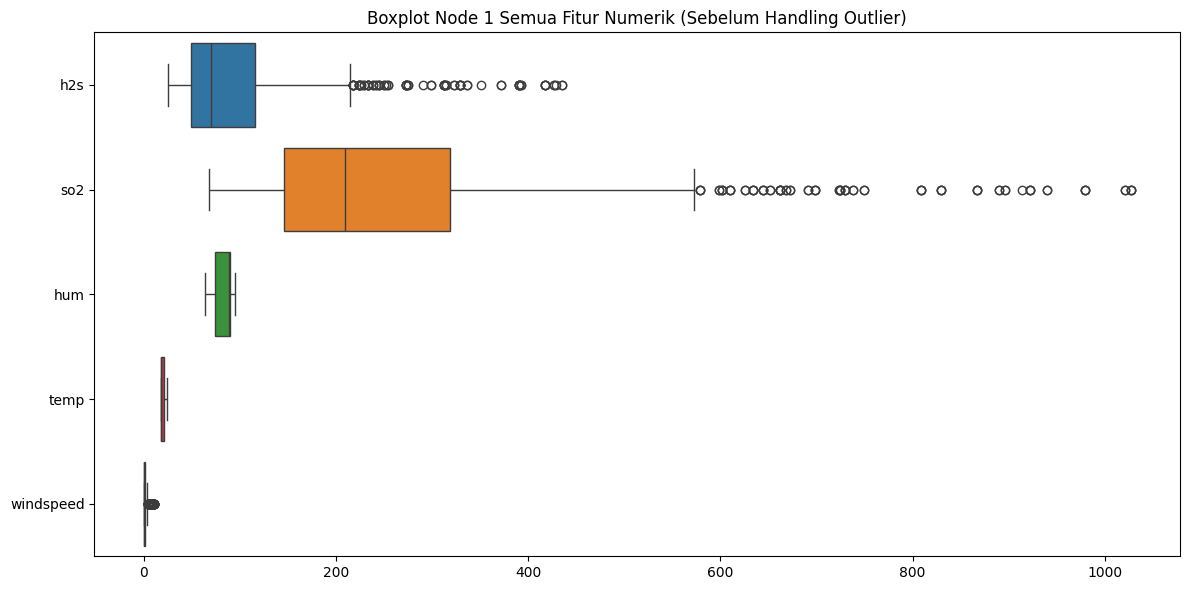

Jumlah outlier Node 1 per kolom sebelum handling:
h2s: 38
so2: 27
hum: 0
temp: 0
windspeed: 43

--- Applying 'cap' strategy for Node 1 ---

Jumlah outlier Node 1 setelah handling:
h2s: 76
so2: 74
hum: 0
temp: 0
windspeed: 57


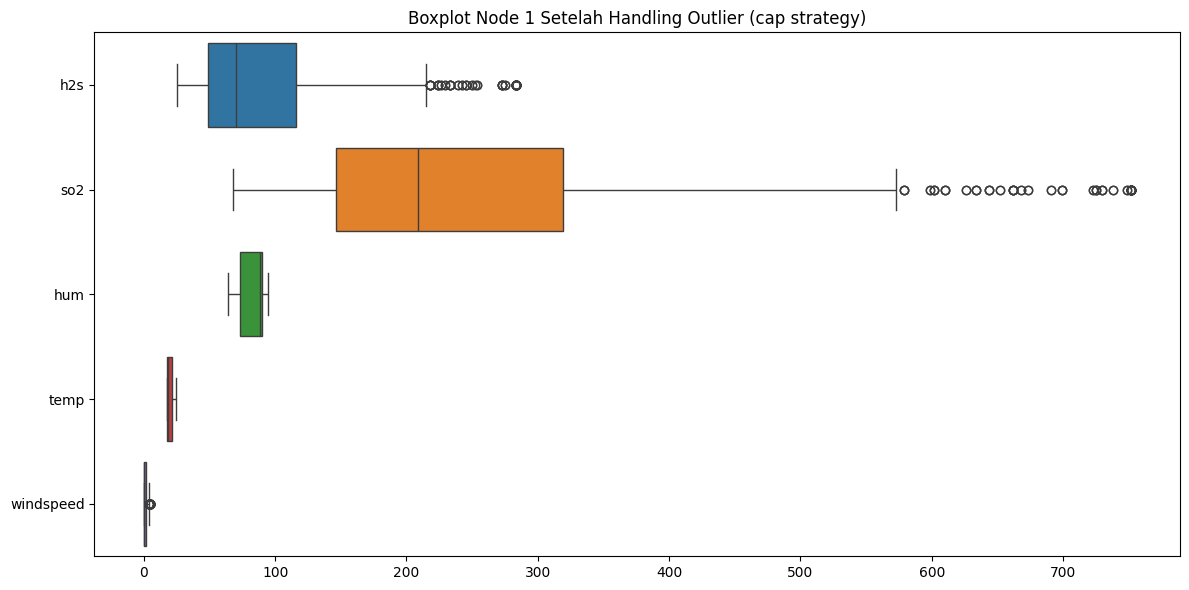


======== Processing df2 (Node 2) ========



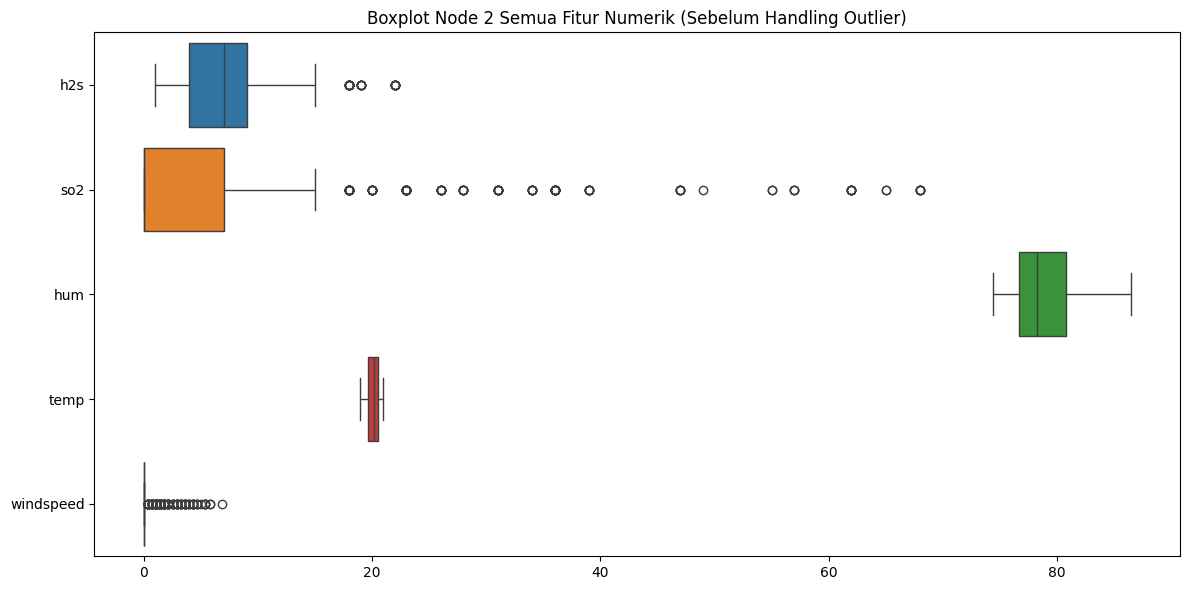

Jumlah outlier Node 2 per kolom sebelum handling:
h2s: 8
so2: 72
hum: 0
temp: 0
windspeed: 144

--- Applying 'cap' strategy for Node 2 ---

Jumlah outlier Node 2 setelah handling:
h2s: 27
so2: 127
hum: 0
temp: 0
windspeed: 0


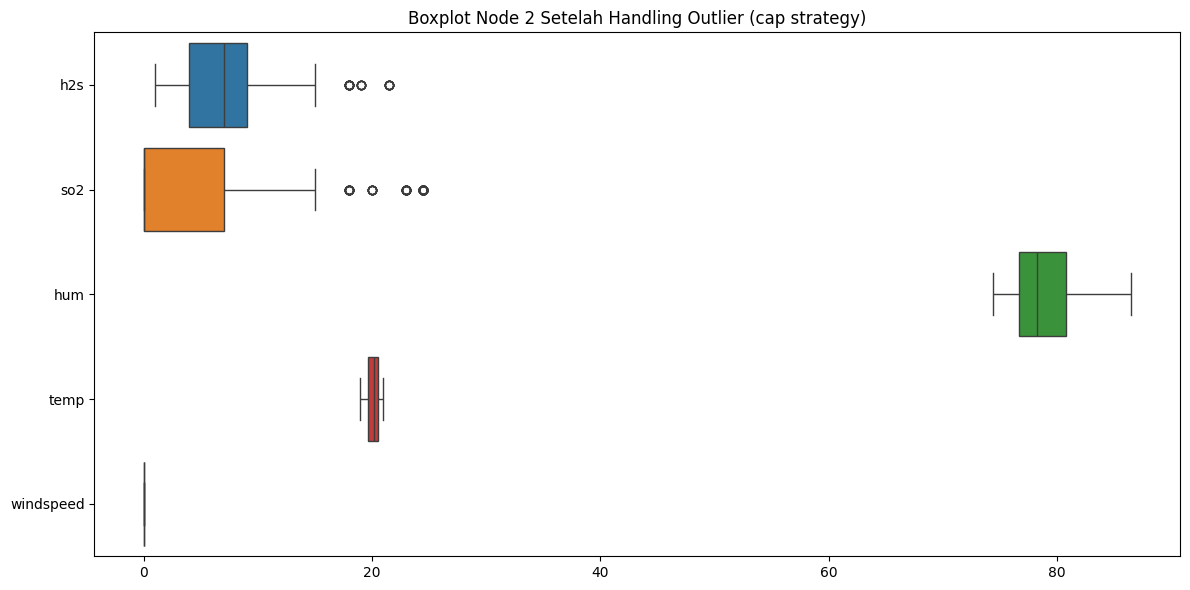


======== Processing df3 (Node 3) ========



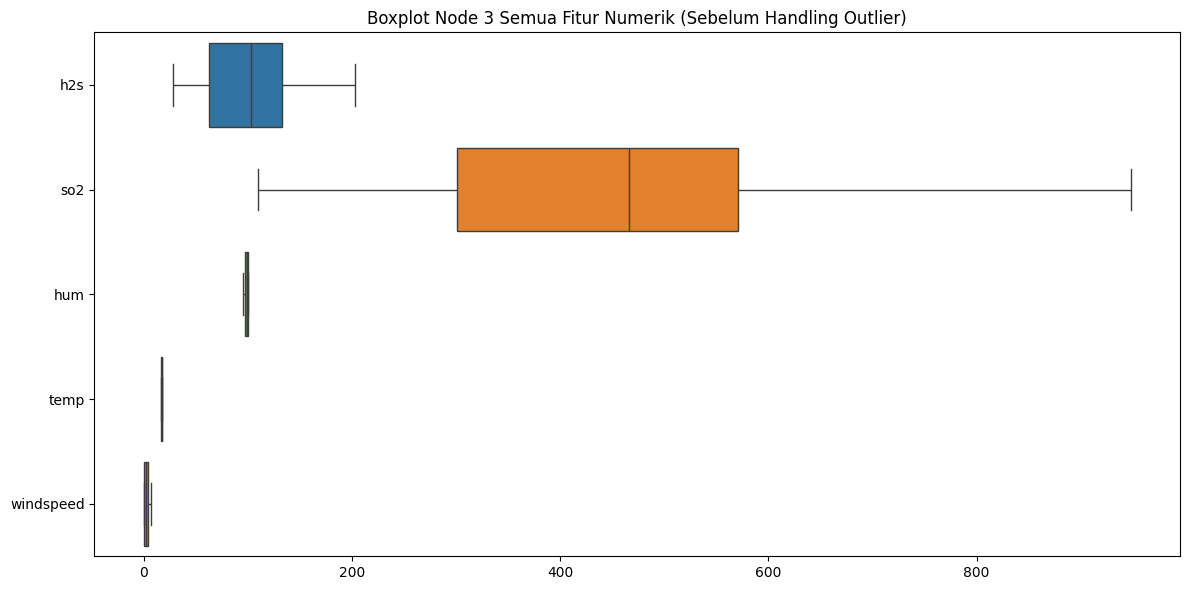

Jumlah outlier Node 3 per kolom sebelum handling:
h2s: 0
so2: 0
hum: 0
temp: 0
windspeed: 0

--- Applying 'cap' strategy for Node 3 ---

Jumlah outlier Node 3 setelah handling:
h2s: 0
so2: 0
hum: 0
temp: 0
windspeed: 0


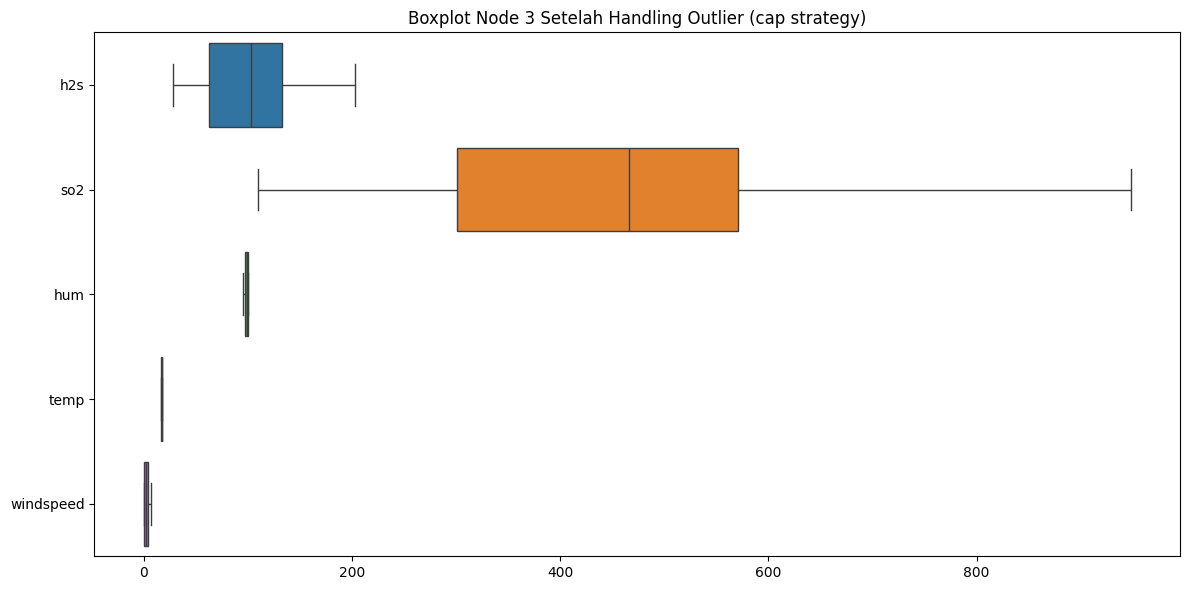


======== Processing df4 (Node 4) ========



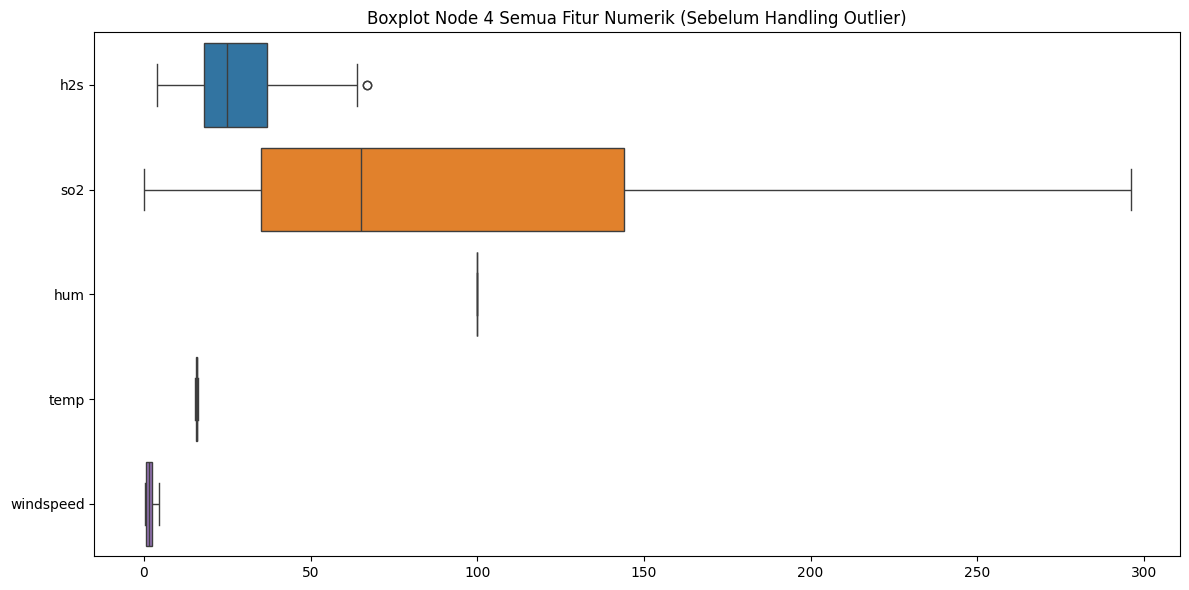

Jumlah outlier Node 4 per kolom sebelum handling:
h2s: 0
so2: 0
hum: 0
temp: 0
windspeed: 0

--- Applying 'cap' strategy for Node 4 ---

Jumlah outlier Node 4 setelah handling:
h2s: 2
so2: 0
hum: 0
temp: 0
windspeed: 0


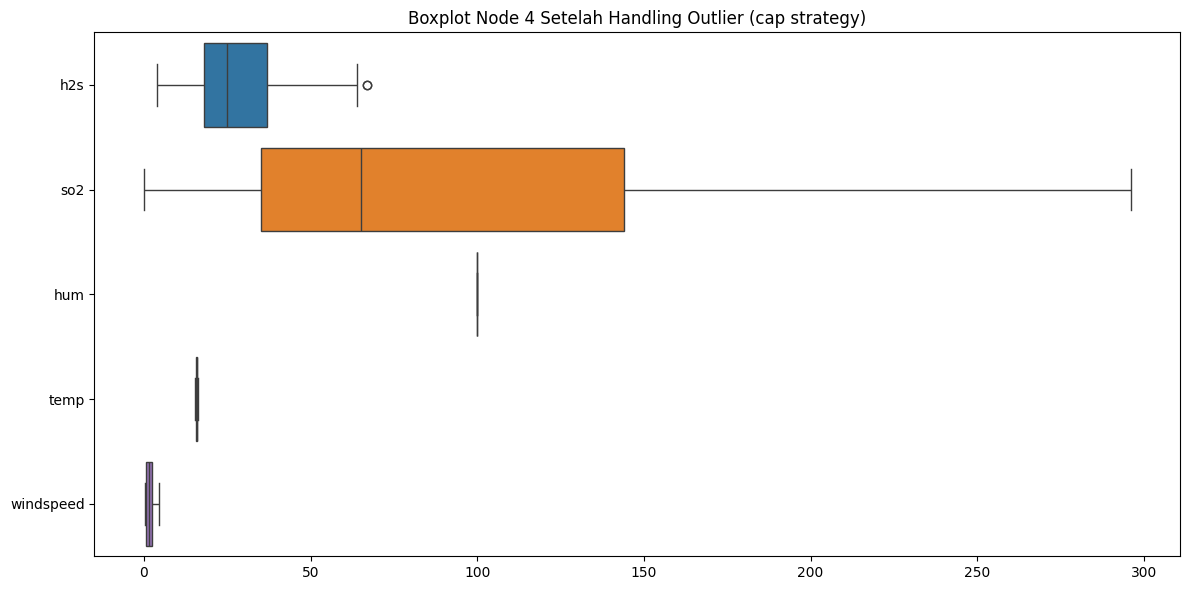


======== Processing df5 (Node 5) ========



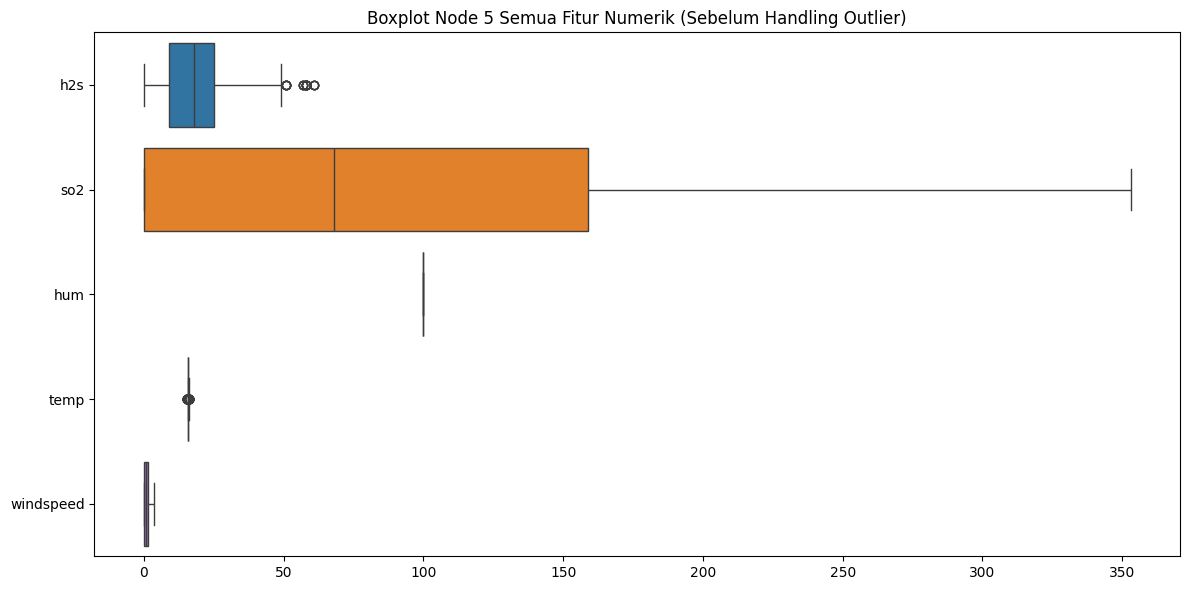

Jumlah outlier Node 5 per kolom sebelum handling:
h2s: 0
so2: 0
hum: 0
temp: 46
windspeed: 0

--- Applying 'cap' strategy for Node 5 ---

Jumlah outlier Node 5 setelah handling:
h2s: 23
so2: 0
hum: 0
temp: 102
windspeed: 0


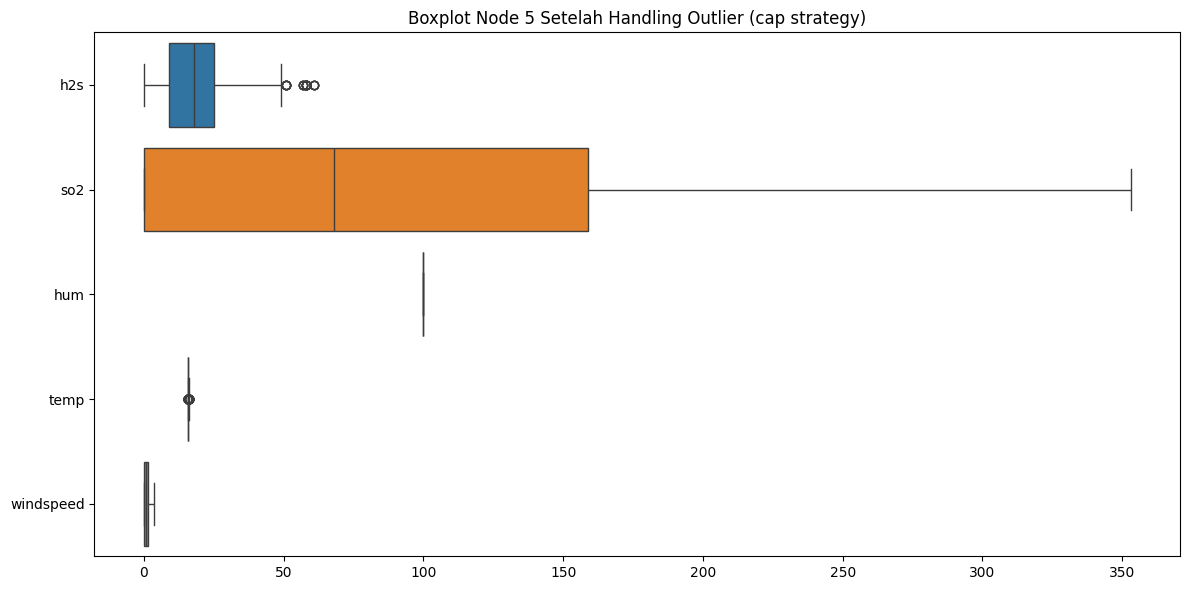


======== Processing df6 (Node 6) ========



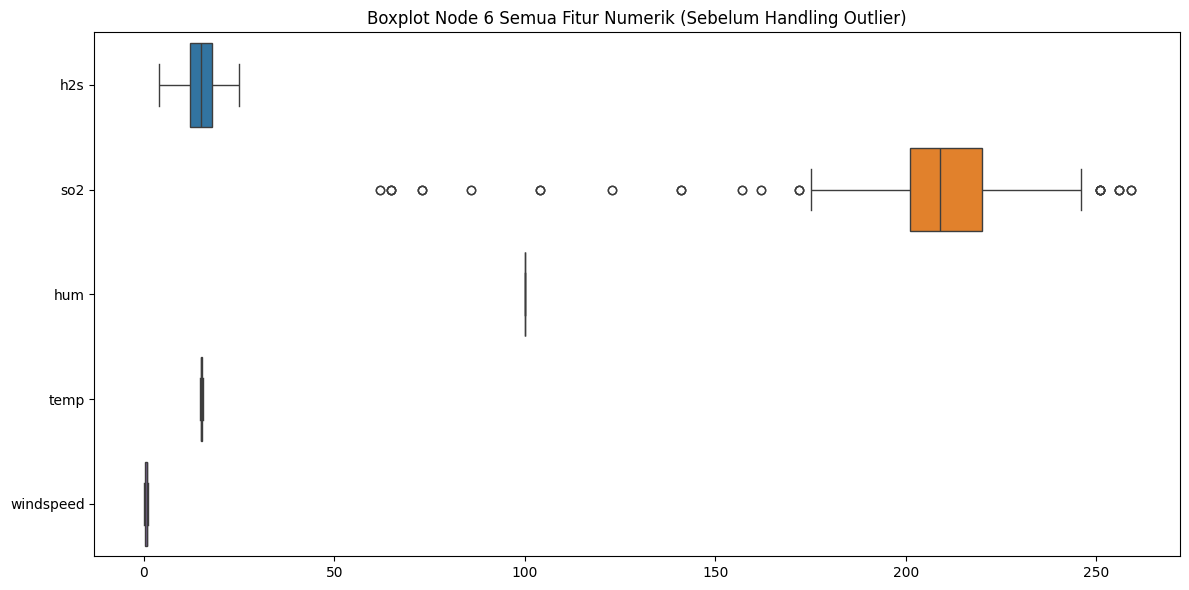

Jumlah outlier Node 6 per kolom sebelum handling:
h2s: 0
so2: 19
hum: 0
temp: 0
windspeed: 0

--- Applying 'cap' strategy for Node 6 ---

Jumlah outlier Node 6 setelah handling:
h2s: 0
so2: 39
hum: 0
temp: 0
windspeed: 0


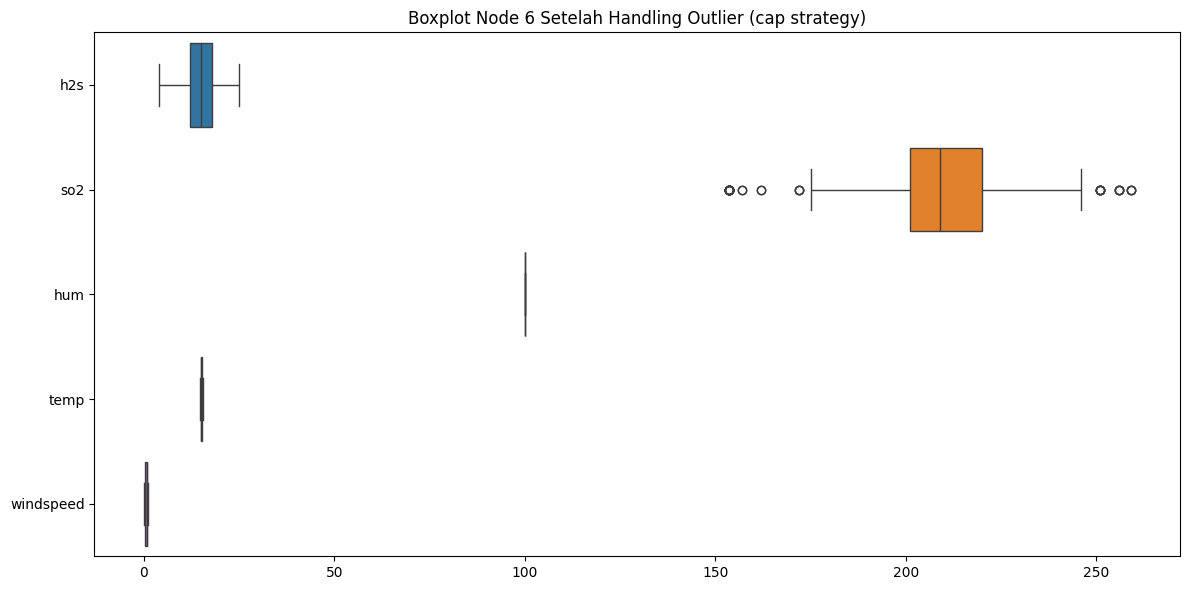


Outlier handling completed for all specified nodes (df1-df6).


In [ ]:
## Preprocessing

# --- Pilih kolom numerik ---
num_cols = ["h2s", "so2", "hum", "temp", "windspeed"]

strategy = 'cap'  # pilihan: 'remove', 'cap', 'robust'

node_scalers = {} # Initialize a dictionary to store fitted scalers for each node

def handle_outliers_for_node(df_node, node_id, num_cols, strategy):
    """Applies outlier handling to a single node DataFrame."""

    # --- Convert kolom ke numeric (handle string / unknown) ---
    for col in num_cols:
        df_node[col] = pd.to_numeric(df_node[col], errors='coerce')  # invalid -> NaN

    # Visualisasi boxplot sebelum handling
    plt.figure(figsize=(12, 6))
    sns.boxplot(data=df_node[num_cols], orient='h')
    plt.title(f"Boxplot Node {node_id} Semua Fitur Numerik (Sebelum Handling Outlier)")
    plt.tight_layout()
    plt.show()

    # Hitung jumlah outlier per kolom pakai IQR sebelum handling
    outlier_summary_before = {}
    for col in num_cols:
        Q1 = df_node[col].quantile(0.25)
        Q3 = df_node[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 2.5 * IQR
        upper = Q3 + 2.5 * IQR
        outliers = ((df_node[col] < lower) | (df_node[col] > upper)).sum()
        outlier_summary_before[col] = outliers

    print(f"Jumlah outlier Node {node_id} per kolom sebelum handling:")
    for k, v in outlier_summary_before.items():
        print(f"{k}: {v}")

    ########################
    print(f"\n--- Applying '{strategy}' strategy for Node {node_id} ---")

    if strategy == 'robust':
        # Robust scaling (tidak menghapus outlier, hanya menstabilkan distribusi)
        scaler = RobustScaler()
        df_node[num_cols] = scaler.fit_transform(df_node[num_cols])
        # Store the fitted scaler for this node
        node_scalers[f'node_{node_id}'] = scaler

    else:
        if strategy == 'remove':
            # Buat mask global biar tidak kepotong berkali-kali
            mask = np.ones(len(df_node), dtype=bool)

        for col in num_cols:
            Q1 = df_node[col].quantile(0.25)
            Q3 = df_node[col].quantile(0.75)
            IQR = Q3 - Q1

            lower = Q1 - 2.5 * IQR
            upper = Q3 + 2.5 * IQR

            if strategy == 'remove':
                mask &= (df_node[col] >= lower) & (df_node[col] <= upper)

            elif strategy == 'cap':
                df_node[col] = df_node[col].clip(lower, upper)

        if strategy == 'remove':
            df_node = df_node[mask].copy() # Use .copy() to avoid SettingWithCopyWarning

    # Hitung jumlah outlier per kolom pakai IQR setelah handling
    outlier_summary_after = {}
    for col in num_cols:
        Q1 = df_node[col].quantile(0.25)
        Q3 = df_node[col].quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        outliers = ((df_node[col] < lower) | (df_node[col] > upper)).sum()
        outlier_summary_after[col] = outliers

    print(f"\nJumlah outlier Node {node_id} setelah handling:")
    for k, v in outlier_summary_after.items():
        print(f"{k}: {v}")

    plt.figure(figsize=(12, 6))
    sns.boxplot(data=df_node[num_cols], orient='h')
    plt.title(f"Boxplot Node {node_id} Setelah Handling Outlier ({strategy} strategy)")
    plt.tight_layout()
    plt.show()

    return df_node

# Apply outlier handling to each node dataframe
for i in range(1, 7):
    df_name = f"df{i}"
    # Ensure node-specific dataframes (df1-df6) are created if not already present
    # This assumes df1-df6 are already available in globals from previous steps
    if df_name not in globals():
        print(f"Warning: {df_name} not found. Skipping outlier handling for this node.")
        continue

    print(f"\n======== Processing {df_name} (Node {i}) ========\n")
    globals()[df_name] = handle_outliers_for_node(globals()[df_name].copy(), i, num_cols, strategy)

print("\nOutlier handling completed for all specified nodes (df1-df6).")

In [ ]:
df_combined_final = pd.concat([df1, df2, df3, df4, df5, df6], ignore_index=True)
print(f"Combined DataFrame shape: {df_combined_final.shape}")
print(df_combined_final.tail())

Combined DataFrame shape: (2895, 12)
      node                 location      weather             datetime  h2s  \
2890     6  Tangga Masuk Pengunjung  Hujan Kabut  2025-12-22 16:43:24  7.0   
2891     6  Tangga Masuk Pengunjung  Hujan Kabut  2025-12-22 16:43:26  7.0   
2892     6  Tangga Masuk Pengunjung  Hujan Kabut  2025-12-22 16:43:28  7.0   
2893     6  Tangga Masuk Pengunjung  Hujan Kabut  2025-12-22 16:43:30  7.0   
2894     6  Tangga Masuk Pengunjung  Hujan Kabut  2025-12-22 16:43:32  7.0   

        so2    hum   temp  windspeed  elevation  latitude  longitude  
2890  153.5  100.0  14.71       0.36     2200.0 -7.166833  107.40411  
2891  153.5  100.0  14.71       0.72     2200.0 -7.166833  107.40411  
2892  153.5  100.0  14.71       0.72     2200.0 -7.166833  107.40411  
2893  153.5  100.0  14.71       0.72     2200.0 -7.166833  107.40411  
2894  153.5  100.0  14.71       0.36     2200.0 -7.166833  107.40411  


In [ ]:
df_combined_final.to_csv('node_combined_final.csv', index=False)

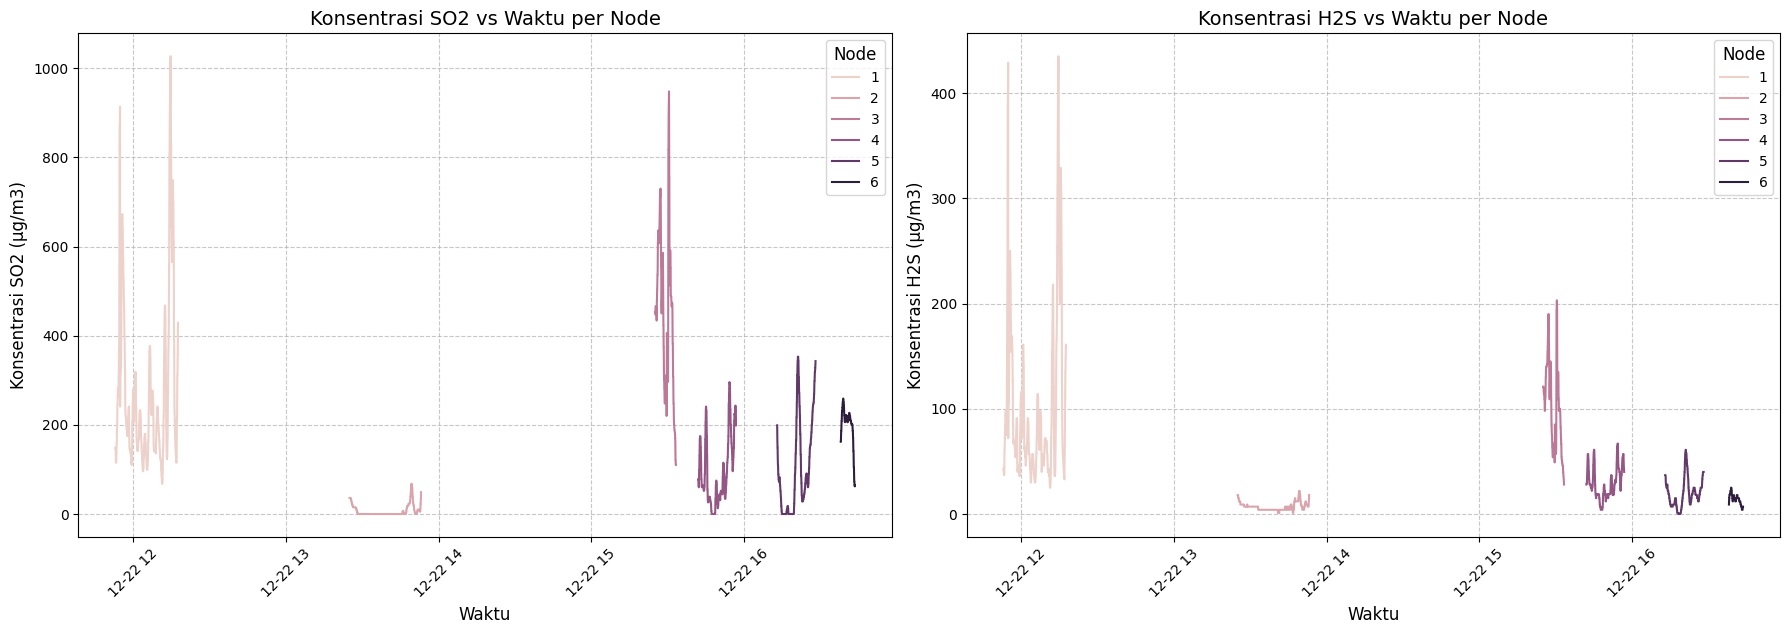

In [ ]:
# Create subplots for better separation and scientific clarity
fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharex=True, sharey=False)

df_combined_final = pd.read_csv('node_combined.csv')
df_combined_final['datetime'] = pd.to_datetime(df_combined_final['datetime'])

# plot SO2
sns.lineplot(data=df_combined_final, x="datetime", y="so2", hue="node", ax=axes[0])
axes[0].set_title("Konsentrasi SO2 vs Waktu per Node", fontsize=14)
axes[0].set_xlabel("Waktu", fontsize=12)
axes[0].set_ylabel("Konsentrasi SO2 (μg/m3)", fontsize=12)
axes[0].legend(title="Node", fontsize=10, title_fontsize=12)
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(True, linestyle='--', alpha=0.7)

# plot H2S
sns.lineplot(data=df_combined_final, x="datetime", y="h2s", hue="node", ax=axes[1])
axes[1].set_title("Konsentrasi H2S vs Waktu per Node", fontsize=14)
axes[1].set_xlabel("Waktu", fontsize=12)
axes[1].set_ylabel("Konsentrasi H2S (μg/m3)", fontsize=12)
axes[1].legend(title="Node", fontsize=10, title_fontsize=12)
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()